<a href="https://colab.research.google.com/github/Kekatumelo/Follow-Along-Tutorials/blob/main/SalesDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving Sales_Data.zip to Sales_Data.zip


In [5]:
import zipfile
import os

with zipfile.ZipFile('Sales_Data.zip', 'r') as zip_ref:
    zip_ref.extractall('sales_data')  # creates a folder

# Check the files
os.listdir('sales_data')


['Sales_Data']

In [16]:
import pandas as pd
import os

folder_path = '/content/sales_data/Sales_Data'  # or wherever your files are

files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]
print("Files found:", files)

all_months_data = pd.DataFrame()

for file in files:
    file_path = os.path.join(folder_path, file)
    try:
        df = pd.read_csv(file_path)
        all_months_data = pd.concat([all_months_data, df])
    except Exception as e:
        print(f"Error reading {file}: {e}")

print("Combined shape:", all_months_data.shape)

# Save again
all_months_data.to_csv('all_data.csv', index=False)


Files found: ['Sales_March_2019.csv', 'Sales_June_2019.csv', 'Sales_February_2019.csv', 'Sales_October_2019.csv', 'Sales_May_2019.csv', 'Sales_November_2019.csv', 'Sales_July_2019.csv', 'Sales_December_2019.csv', 'Sales_January_2019.csv', 'Sales_September_2019.csv', 'Sales_April_2019.csv', 'Sales_August_2019.csv']
Combined shape: (186850, 6)


In [17]:
all_data = pd.read_csv('all_data.csv')
all_data.head()



,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,162009,iPhone,1,700,03/28/19 20:59,"942 Church St, Austin, TX 73301"
1,162009,Lightning Charging Cable,1,14.95,03/28/19 20:59,"942 Church St, Austin, TX 73301"
2,162009,Wired Headphones,2,11.99,03/28/19 20:59,"942 Church St, Austin, TX 73301"
3,162010,Bose SoundSport Headphones,1,99.99,03/17/19 05:39,"261 10th St, San Francisco, CA 94016"
4,162011,34in Ultrawide Monitor,1,379.99,03/10/19 00:01,"764 13th St, San Francisco, CA 94016"


In [19]:

all_data = all_data[all_data['Order Date'] != 'Order Date']

all_data['Order Date'] = pd.to_datetime(all_data['Order Date'], format='%m/%d/%y %H:%M')



In [24]:
all_data['Month'] = all_data['Order Date'].dt.month_name()



In [25]:
unique_values = all_data['Month'].unique()
print(unique_values)


['March' 'April' 'June' 'July' 'February' 'October' 'November' 'May'
 'December' 'August' 'January' 'September']


In [23]:
all_data = all_data.dropna(subset=['Order Date'])


In [31]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])

In [32]:
all_data['Total Price']= all_data['Quantity Ordered']*all_data['Price Each']

In [43]:
Monthly_sales = all_data.groupby('Month')['Total Price'].sum().sort_values(ascending=False)
Monthly_sales

,Total Price
Month,
December,4613443.34
October,3736726.88
April,3390670.24
November,3199603.20
May,3152606.75
March,2807100.38
July,2647775.76
June,2577802.26
August,2244467.88


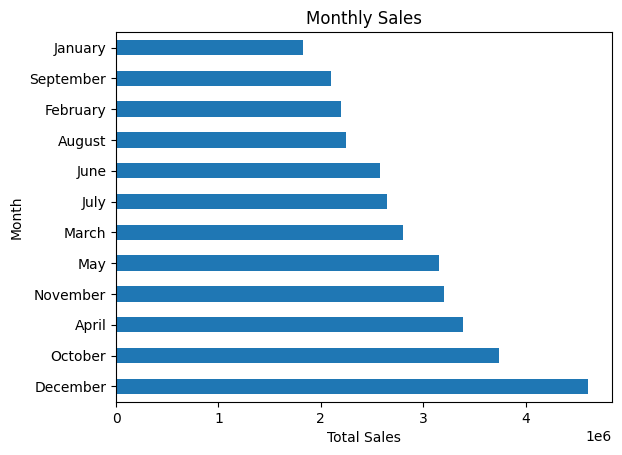

In [49]:
import matplotlib.pyplot as plt

Monthly_sales.plot(kind='barh', title='Monthly Sales')
plt.xlabel('Total Sales')
plt.ylabel('Month')
plt.show()


Which US city had the highest number of sales?

In [51]:
all_data['City'] = all_data['Purchase Address'].apply(lambda x: x.split(',')[1].strip())


In [53]:
unique_cities=all_data['City'].unique()
unique_cities

array(['Austin', 'San Francisco', 'Boston', 'Atlanta', 'Portland',
       'Dallas', 'Los Angeles', 'New York City', 'Seattle'], dtype=object)

In [54]:
all_data.groupby('City')['Total Price'].sum().sort_values(ascending=False)

,Total Price
City,
San Francisco,8262203.91
Los Angeles,5452570.80
New York City,4664317.43
Boston,3661642.01
Atlanta,2795498.58
Dallas,2767975.40
Seattle,2747755.48
Portland,2320490.61
Austin,1819581.75


At what time should we display advertisments to maximize likelihood of customers buying our products?

In [55]:
all_data['Hour'] = all_data['Order Date'].dt.hour

In [57]:
hourly_sales = all_data.groupby('Hour')['Total Price'].sum().sort_values(ascending=False)

In [58]:
hourly_sales

,Total Price
Hour,
19,2412938.54
12,2316821.34
11,2300610.24
20,2281716.24
18,2219348.30
13,2155389.80
17,2129361.61
14,2083672.73
21,2042000.86


at hour 19:00

What product sold the most?

In [76]:
most_sold= all_data.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

In [77]:
most_sold

,Quantity Ordered
Product,
AAA Batteries (4-pack),31017
AA Batteries (4-pack),27635
USB-C Charging Cable,23975
Lightning Charging Cable,23217
Wired Headphones,20557
Apple Airpods Headphones,15661
Bose SoundSport Headphones,13457
27in FHD Monitor,7550
iPhone,6849
